## Compensação Financeira pela Exploração de Recursos Minerais (CFEM)

Dados Disponivel: [link](https://dados.gov.br/dados/conjuntos-dados/sistema-arrecadacao)

In [1]:
%reset -f #limpar ambiente

Don't know how to reset  #limpar, please run `%reset?` for details
Don't know how to reset  ambiente, please run `%reset?` for details


Pacotes Externos

In [3]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from Funcoes_e_codigos_complementares import * # Modulo necessario
from google.cloud import bigquery

In [5]:
dados = pd.read_csv("/content/CFEM_Arrecadacao_2022_2026.csv",encoding = "latin-1") # lendo conjuntos de dados da
#Arrecadação pela CFEM

In [6]:
dados.head() # visualizar as 5 primeiras linhas do data frame

,Ano,Mês,Processo,AnoDoProcesso,Tipo_PF_PJ,CPF_CNPJ,Substância,UF,CodigoMunicipio,Município,QuantidadeComercializada,UnidadeDeMedida,ValorRecolhido,DataCriacao
0,2022,1,826539.0,2016.0,PF,***005909**,ARGILA,PR,4105508,CIANORTE,"70,28",t,"213,72",2021-12-06 14:31:00
1,2022,1,868278.0,2011.0,PF,***024694**,CASCALHO,MS,5007208,RIO BRILHANTE,"4235,29",kg,"703,91",2021-12-10 16:08:00
2,2022,1,884021.0,2015.0,PF,***033488**,AREIA,RR,1400100,BOA VISTA,396,t,"52,3",2021-12-29 14:15:00
3,2022,1,880493.0,2011.0,PF,***041224**,ARGILA,AM,1304062,TABATINGA,"402,65",t,"62,81",2021-12-11 22:26:00
4,2022,1,920047.0,2012.0,PF,***279883**,ÁGUA MINERAL,SP,3539806,POÁ,0,l,"478,5",2014-08-20 00:00:00


In [7]:
dados.rename(columns={'Substância': 'Bens_minerais'}, inplace=True) # Renomeando variavel de recurso mineral

In [8]:
dados.isna().sum() # Contando a quantidade de dados ausentes por variável


,0
Ano,0
Mês,0
Processo,3
AnoDoProcesso,3
Tipo_PF_PJ,0
CPF_CNPJ,0
Bens_minerais,0
UF,40
CodigoMunicipio,0
Município,40


In [9]:
dados.dropna(inplace=True) # Removendo linhas com Presença de NAs em alguma coluna

In [10]:
dados.duplicated().sum() # Quantidade de duplicação

np.int64(3399)

In [11]:
dados = dados.drop_duplicates()
dados.shape

(527117, 14)

In [12]:
dados.info() # informações resumidas das colunas


<class 'pandas.core.frame.DataFrame'>
Index: 527117 entries, 0 to 530609
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Ano                       527117 non-null  int64  
 1   Mês                       527117 non-null  int64  
 2   Processo                  527117 non-null  float64
 3   AnoDoProcesso             527117 non-null  float64
 4   Tipo_PF_PJ                527117 non-null  object 
 5   CPF_CNPJ                  527117 non-null  object 
 6   Bens_minerais             527117 non-null  object 
 7   UF                        527117 non-null  object 
 8   CodigoMunicipio           527117 non-null  int64  
 9   Município                 527117 non-null  object 
 10  QuantidadeComercializada  527117 non-null  object 
 11  UnidadeDeMedida           527117 non-null  object 
 12  ValorRecolhido            527117 non-null  object 
 13  DataCriacao               527117 non-null  object

In [13]:
# Lista das colunas para converter no formato correto
colunas = ['QuantidadeComercializada', 'ValorRecolhido']

# Substituir vírgula por ponto e depois converter para float
for col in colunas:
    dados[col] = dados[col].str.replace(',', '.').astype(float)


In [14]:

unidades_por_bem = (
    dados.groupby('Bens_minerais')['UnidadeDeMedida']
      .nunique()
      .reset_index(name='qtd_unidades')
)

# bens minerais com mais de uma unidade de medida
bens_com_multiplas_unidades = unidades_por_bem[
    unidades_por_bem['qtd_unidades'] > 1
]

print(bens_com_multiplas_unidades)

             Bens_minerais  qtd_unidades
0             AGALMATOLITO             2
3       ALUVIÃO ESTANÍFERO             2
4                 AMETISTA             2
5                  AMIANTO             2
8                ANFIBÓLIO             2
..                     ...           ...
193           ÁGUA MARINHA             2
194           ÁGUA MINERAL             2
196  ÁGUA MINERAL RAD. FON             2
197   ÁGUA POTÁVEL DE MESA             2
198          ÁGUAS TERMAIS             2

[122 rows x 2 columns]


In [15]:
detalhe_unidades = (
    dados[dados['Bens_minerais'].isin(bens_com_multiplas_unidades['Bens_minerais'])]
      .groupby('Bens_minerais')['UnidadeDeMedida']
      .unique()
      .reset_index(name='unidades_usadas')
)

detalhe_unidades.head(10)


,Bens_minerais,unidades_usadas
0,AGALMATOLITO,"[t , kg ]"
1,ALUVIÃO ESTANÍFERO,"[t , kg ]"
2,AMETISTA,"[g , kg ]"
3,AMIANTO,"[t , kg ]"
4,ANFIBÓLIO,"[t , kg ]"
5,ARDÓSIA,"[m3 , t , m2 ]"
6,AREIA,"[t , kg , m3 ]"
7,AREIA ALUVIONAR,"[m3 , t ]"
8,AREIA DE FUNDIÇÃO,"[t , m3 ]"
9,AREIA INDUSTRIAL,"[kg , t , m3 ]"


Como há diversas unidades de medidadas para os bens minerais então é necessário padronizar mas unidades de massa e volume para apenas uma só:.

In [16]:
# Aplicar a padronização
dados_df = padronizar_unidades(dados)

# Verificar resultado
print("Contagem por unidade padronizada:")
print(dados_df['UnidadePadronizada'].value_counts())

# Verificar bens que ainda têm múltiplas unidades
multi_unidades = dados_df.groupby('Bens_minerais')['UnidadePadronizada'].nunique()
problemas = multi_unidades[multi_unidades > 1]
print(f"\nBens com múltiplas unidades após padronização: {len(problemas)}")



Contagem por unidade padronizada:
UnidadePadronizada
m³    395958
t     118930
kg     10073
m²       986
g        921
ct       249
Name: count, dtype: int64

Bens com múltiplas unidades após padronização: 0


Transcrevendo a descrição do Mês de número para nome

In [17]:
meses_pt = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

dados_df['Mês'] = dados_df['Mês'].astype(int).map(meses_pt)



In [18]:

ordem_meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# Transformar coluna em categoria ordenada
dados_df['Mês'] = pd.Categorical(
    dados_df['Mês'],
    categories=ordem_meses,
    ordered=True
)


dados_df['Mês'].value_counts()

,count
Mês,
Mar,63983
Jan,48848
Fev,47081
Abr,43505
Set,42933
Ago,42758
Jul,42110
Mai,41183
Nov,40995


Com a presença de espaços entre os caracteres da coluna "UnidadeDeMedida", o passo a seguir foi remover estes espaços para deixar mais limpo as análises.

In [19]:
dados_df['UnidadeDeMedida'] = dados_df['UnidadeDeMedida'].str.strip()

In [20]:
dados_2025 = dados_df.query("Ano == 2025")

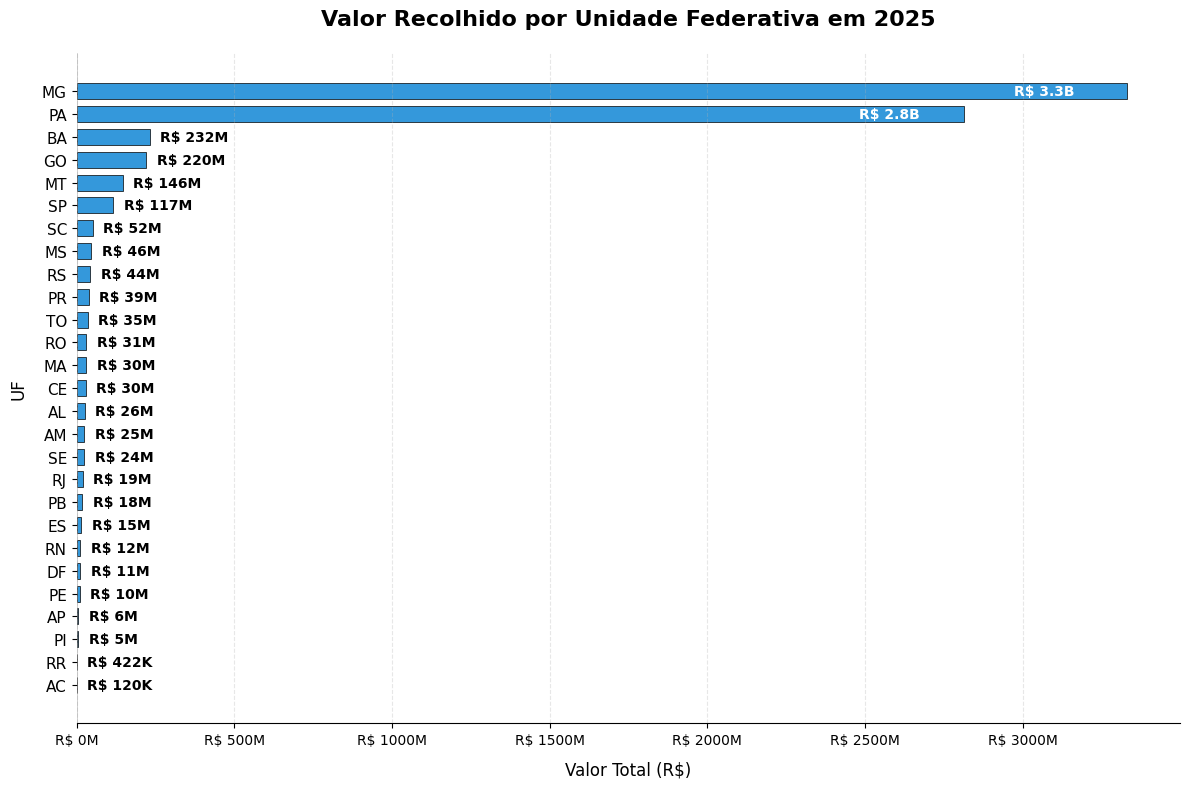

In [22]:

# Exemplo 1: Valor Recolhido por UF (como no seu código original)

fig1, ax1, dados_uf = criar_grafico_barras_horizontais(
    dados=dados_2025,
    x_col='UF',
    y_col='ValorRecolhido',
    titulo='Valor Recolhido por Unidade Federativa em 2025',
    xlabel='Valor Total (R$)',
    ylabel='UF',
    cor='#3498db',  # Azul
    figsize=(12, 8)
)
plt.show()


/tmp/ipython-input-1474023951.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = dados_df.pivot_table(


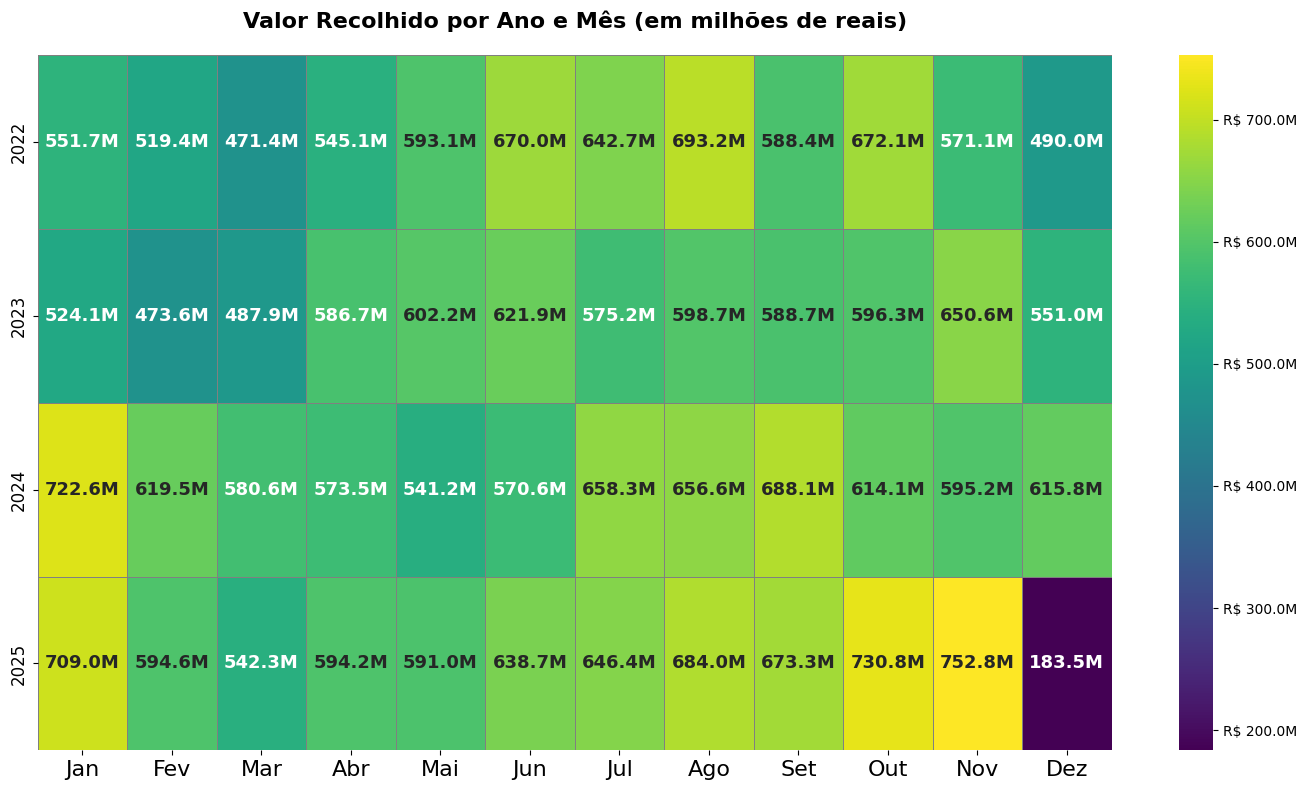

In [23]:

# Criar a pivot table
pivot = dados_df.pivot_table(
    values='ValorRecolhido',
    index='Ano',
    columns='Mês',
    aggfunc='sum'
)

# Formatar os valores para exibir em milhões
pivot_formatted = pivot / 1_000_000  # Converte para milhões

# Configurar o tamanho da figura
plt.figure(figsize=(14, 8))

# Criar o heatmap
heatmap = sns.heatmap(
    pivot_formatted,
    cmap='viridis',
    annot=True,  # Mostrar valores nas células
    fmt='.1f',   # Formato com 2 casas decimais
    annot_kws={"size": 13,
               "fontweight": "bold"},
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={
     #   'label': 'Valor (em milhões R$)',
        'format': ticker.FuncFormatter(lambda x, p: f'R$ {x:,.1f}M')
    }
)

##cbar = heatmap .collections[0].colorbar
#cbar.ax.set_ylabel('Valor (em milhões R$)', fontsize=14)

# Aumentar o tamanho dos rótulos do eixo x (Meses)
plt.xticks(fontsize=16, rotation=0)  # rotation=0 para manter horizontal
plt.yticks(fontsize=12)  # Opcional: também aumentar o eixo y


# Personalizar título e rótulos
plt.title('Valor Recolhido por Ano e Mês (em milhões de reais)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)

# Melhorar a formatação dos valores nas células (opcional - remover decimais se necessário)
for text in heatmap.texts:
    text.set_text(f"{float(text.get_text()):,.1f}M")

plt.tight_layout()
plt.show()


TOP 15 BENS MINERAIS POR QUANTIDADE COMERCIALIZADA


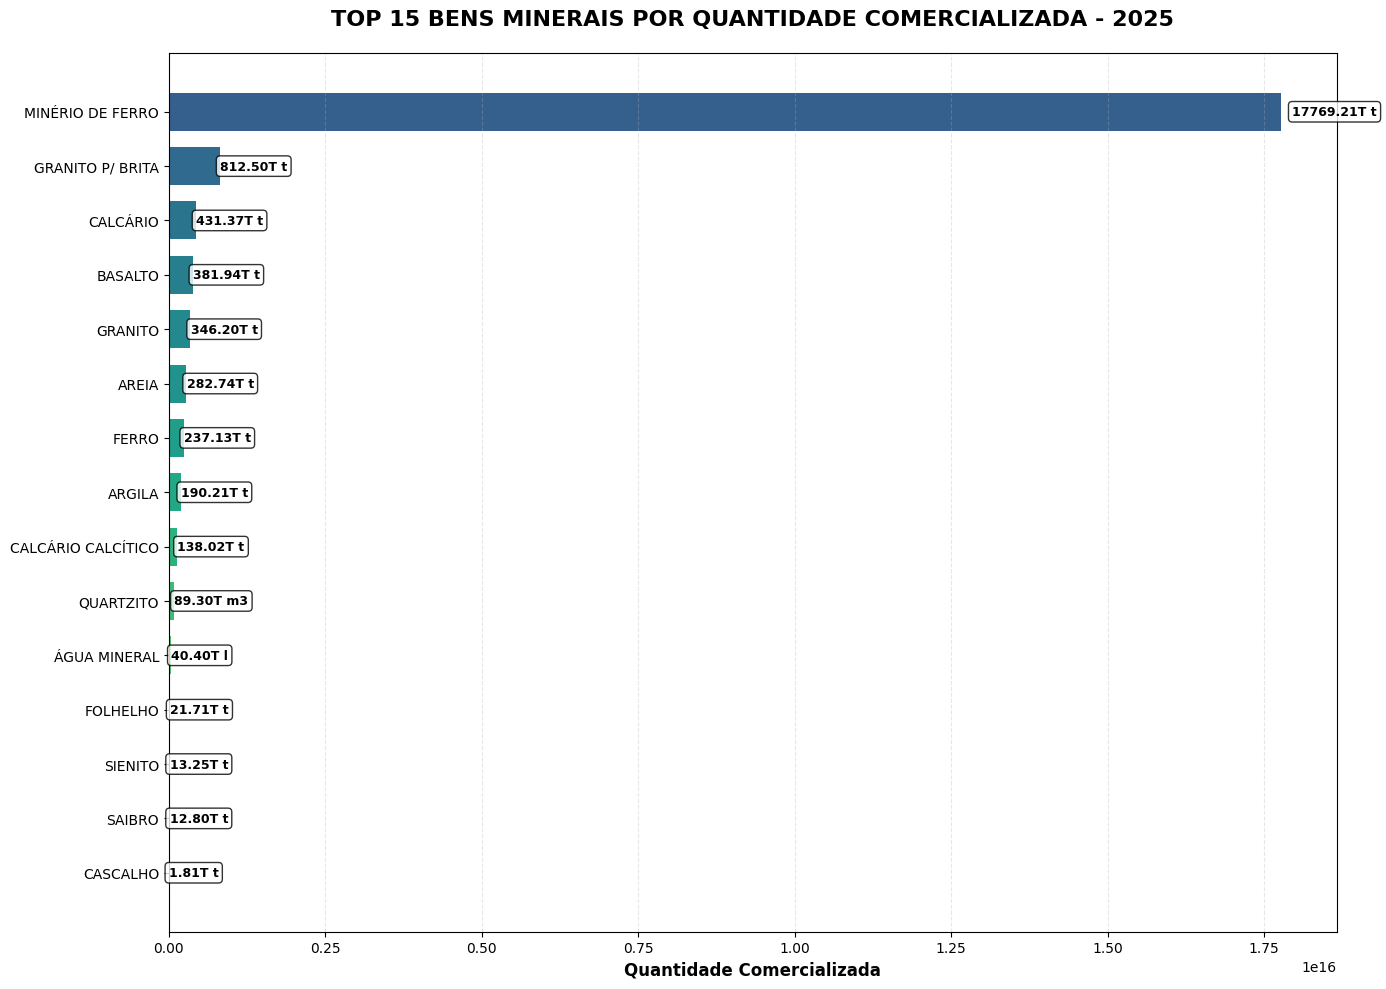


BENS MINERAIS                                                QUANTIDADE    UNIDADE
MINÉRIO DE FERRO                                                      17769.21T t
GRANITO P/ BRITA                                                        812.50T t
CALCÁRIO                                                                431.37T t
BASALTO                                                                 381.94T t
GRANITO                                                                 346.20T t
AREIA                                                                   282.74T t
FERRO                                                                   237.13T t
ARGILA                                                                  190.21T t
CALCÁRIO CALCÍTICO                                                      138.02T t
QUARTZITO                                                               89.30T m3
ÁGUA MINERAL                                                             40.40T l
FOLHELHO      

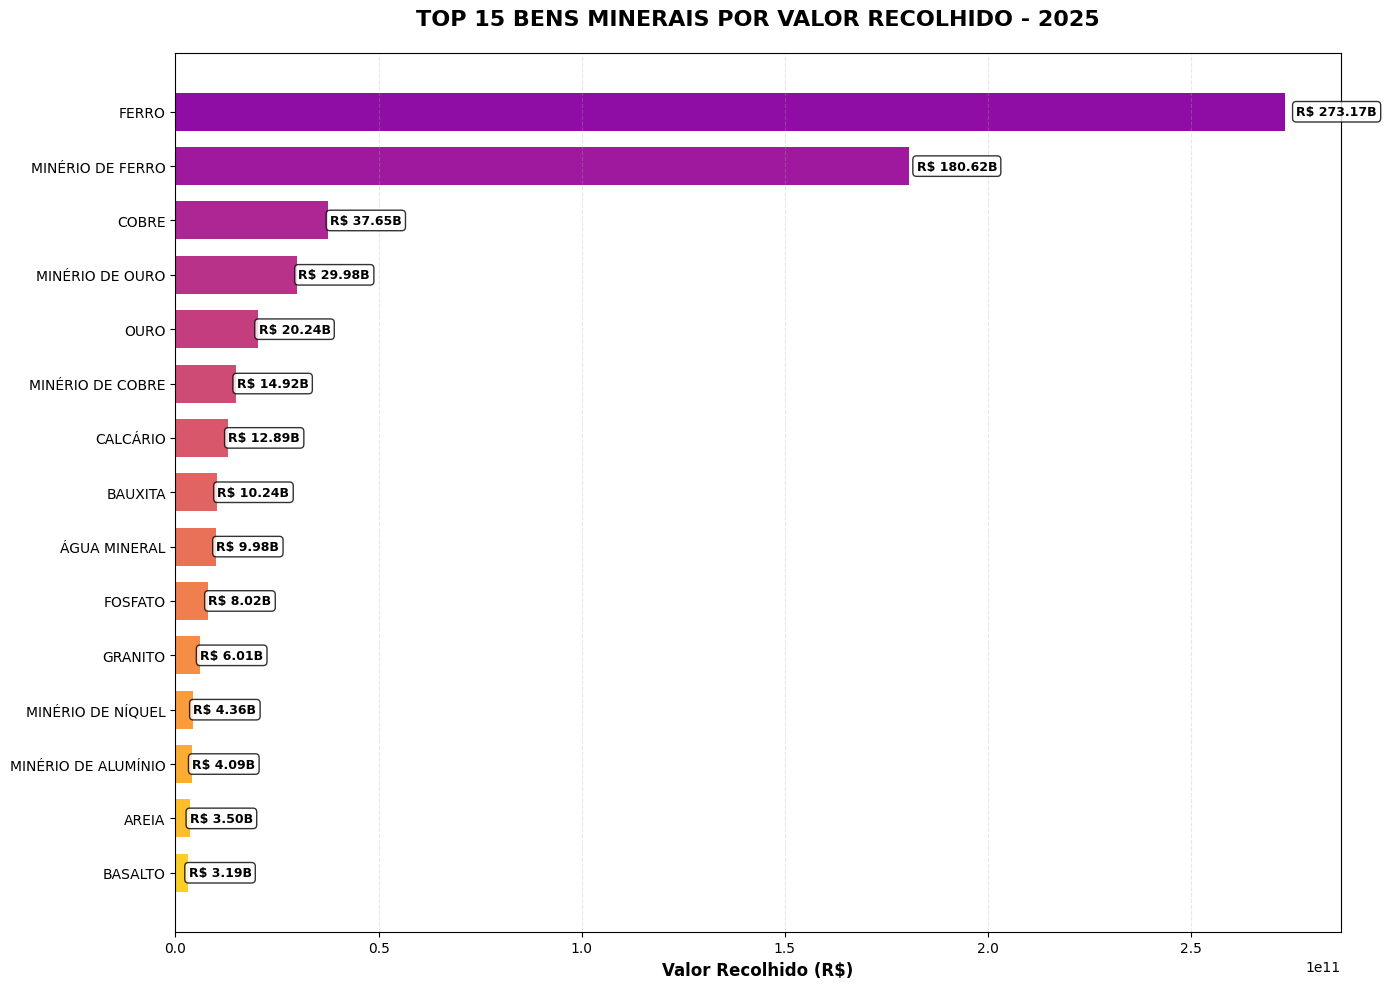


BENS MINERAIS                                                VALOR RECOLHIDO MUNICÍPIOS
FERRO                                                             R$ 273.17B         25
MINÉRIO DE FERRO                                                  R$ 180.62B         61
COBRE                                                              R$ 37.65B          6
MINÉRIO DE OURO                                                    R$ 29.98B         60
OURO                                                               R$ 20.24B         31
MINÉRIO DE COBRE                                                   R$ 14.92B         11
CALCÁRIO                                                           R$ 12.89B        196
BAUXITA                                                            R$ 10.24B         19
ÁGUA MINERAL                                                        R$ 9.98B        401
FOSFATO                                                             R$ 8.02B         13
GRANITO                        

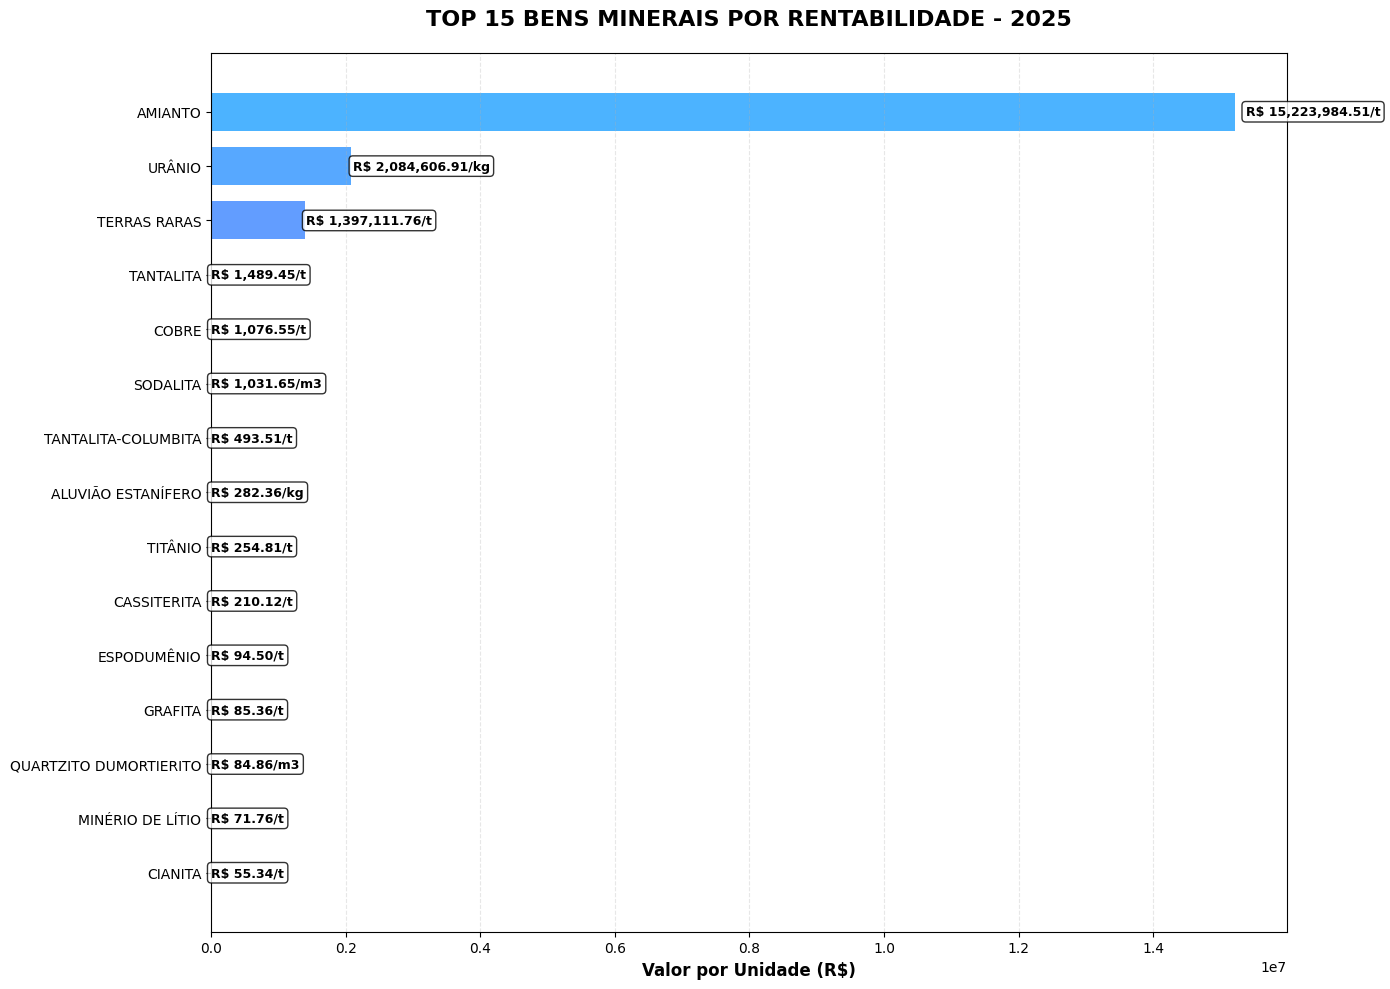


BENS MINERAIS                                                R$/UNIDADE    UNIDADE
AMIANTO                                            R$   15,223,984.51/         t
URÂNIO                                             R$    2,084,606.91/        kg
TERRAS RARAS                                       R$    1,397,111.76/         t
TANTALITA                                          R$        1,489.45/         t
COBRE                                              R$        1,076.55/         t
SODALITA                                           R$        1,031.65/        m3
TANTALITA-COLUMBITA                                R$          493.51/         t
ALUVIÃO ESTANÍFERO                                 R$          282.36/        kg
TITÂNIO                                            R$          254.81/         t
CASSITERITA                                        R$          210.12/         t
ESPODUMÊNIO                                        R$           94.50/         t
GRAFITA                  

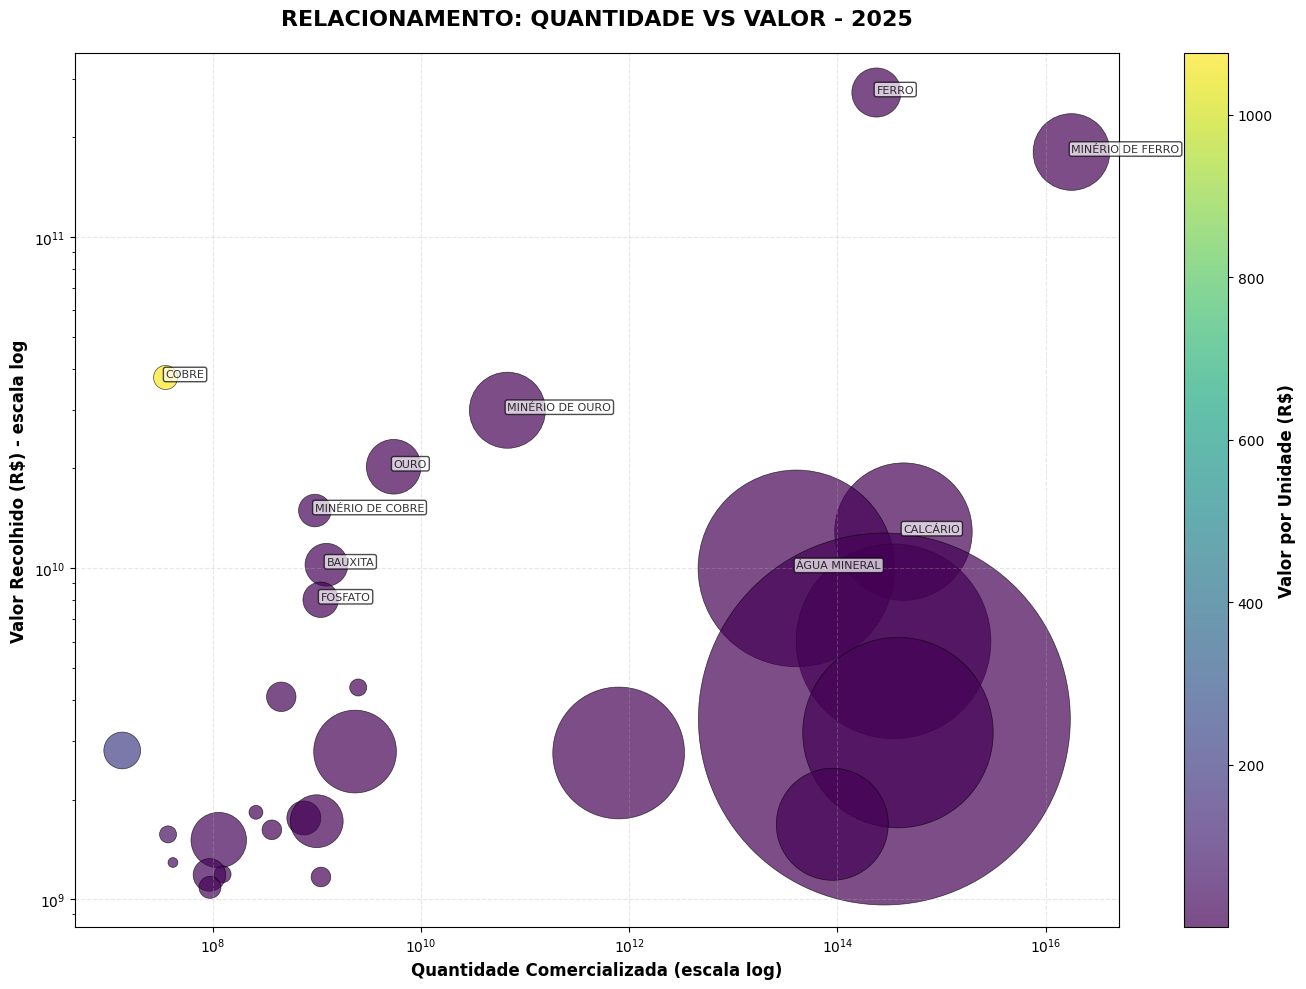


RESUMO ESTATÍSTICO - 2025

Total de tipos diferentes: 185
Com dados comerciais: 179

ESTATÍSTICAS GERAIS:
------------------------------------------------------------
Quantidade total: 20773.15T
Valor total: R$ 661.97B
Valor médio por unidade: R$ 104,535.83
Média de municípios: 31.6

Dados exportados para: analise_bens_minerais.csv


In [24]:
'''
   Exemplo de como usar a função:

    # Supondo que você tenha um DataFrame chamado 'dados_2025'
    resultado = analisar_bens_minerais(
        df=dados_2025,
        col_bens='Bens_minerais',
        col_quantidade='QuantidadeComercializada',
        col_valor='ValorRecolhido',
        col_municipio='Município',
        col_unidade='UnidadeDeMedida',
        titulo_principal='BENS MINERAIS',
        ano='2025',
        cor_quantidade='viridis',
        cor_valor='plasma',
        cor_rentabilidade='cool',
        n_top=15,
        exportar_csv=True,
        nome_arquivo='analise_bens_minerais_2025.csv'
    )

'''
resultado = analisar_bens_minerais(dados_2025, cor_valor= 'plasma')

Armazendo dados no BigQuery


In [ ]:
from google.colab import auth
from google.cloud import bigquery


# Configuração rápida
auth.authenticate_user() # Autenticação no Google Cloud
PROJECT_ID = "mineracaocfem"
DATASET_ID = "exportacoes_colab"
TABLE_ID = "dados_mineração_GO"

# Criar cliente
client = bigquery.Client(project=PROJECT_ID)

# Criar dataset se não existir
try:
    client.get_dataset(DATASET_ID)
except:
    dataset = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_ID}")
    dataset.location = "southamerica-east1"
    client.create_dataset(dataset)
    print(f"Dataset '{DATASET_ID}' criado")


# Exportar
table_ref = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"
job = client.load_table_from_dataframe(dados_df, table_ref)
job.result()

print(f" Dados exportados para: {table_ref}")
print(f" {job.output_rows} linhas inseridas")

✅ Dados exportados para: mineracaocfem.exportacoes_colab.dados_mineração_GO
📊 527117 linhas inseridas


In [ ]:
#dados_df.to_csv('/content/dados_mineração.csv', index=False)
